In [11]:
!pip install pathlib

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shutil
import os
import warnings
warnings.filterwarnings('ignore')

In [17]:
BASE = Path('data')

In [18]:
DAILY = Base/'daily'

In [21]:
BASE

WindowsPath('data')

In [20]:
Daily

WindowsPath('data/daily')

In [22]:
daily_files = sorted(DAILY.glob('*.csv'))
len(daily_files), daily_files

(91,
 [WindowsPath('data/daily/2026-01-01.csv'),
  WindowsPath('data/daily/2026-01-02.csv'),
  WindowsPath('data/daily/2026-01-03.csv'),
  WindowsPath('data/daily/2026-01-04.csv'),
  WindowsPath('data/daily/2026-01-05.csv'),
  WindowsPath('data/daily/2026-01-06.csv'),
  WindowsPath('data/daily/2026-01-07.csv'),
  WindowsPath('data/daily/2026-01-08.csv'),
  WindowsPath('data/daily/2026-01-09.csv'),
  WindowsPath('data/daily/2026-01-10.csv'),
  WindowsPath('data/daily/2026-01-11.csv'),
  WindowsPath('data/daily/2026-01-12.csv'),
  WindowsPath('data/daily/2026-01-13.csv'),
  WindowsPath('data/daily/2026-01-14.csv'),
  WindowsPath('data/daily/2026-01-15.csv'),
  WindowsPath('data/daily/2026-01-16.csv'),
  WindowsPath('data/daily/2026-01-17.csv'),
  WindowsPath('data/daily/2026-01-18.csv'),
  WindowsPath('data/daily/2026-01-19.csv'),
  WindowsPath('data/daily/2026-01-20.csv'),
  WindowsPath('data/daily/2026-01-21.csv'),
  WindowsPath('data/daily/2026-01-22.csv'),
  WindowsPath('data/daily/2

In [24]:
daily_frames = [pd.read_csv(file) for file in daily_files if 'new_day' not in file.name]
daily_frames

[         Date Account_ID Transaction_Type  Amount     Branch
 0  2026-01-01       A008          Deposit   37000     Lahore
 1  2026-01-01       A009       Withdrawal   11500  Islamabad
 2  2026-01-01       A001       Withdrawal   37000    Karachi
 3  2026-01-01       A008       Withdrawal   26500     Lahore
 4  2026-01-01       A002          Deposit   42500     Lahore
 5  2026-01-01       A004       Withdrawal   39500    Karachi
 6  2026-01-01       A007       Withdrawal   28000    Karachi,
          Date Account_ID Transaction_Type  Amount     Branch
 0  2026-01-02       A005       Withdrawal   12500     Lahore
 1  2026-01-02       A009       Withdrawal    5000  Islamabad
 2  2026-01-02       A003       Withdrawal   32000  Islamabad
 3  2026-01-02       A008       Withdrawal   19000     Lahore
 4  2026-01-02       A005       Withdrawal   44500     Lahore
 5  2026-01-02       A008          Deposit   19500     Lahore
 6  2026-01-02       A005          Deposit    8000     Lahore
 7  202

In [25]:
transactions = pd.concat(daily_frames, ignore_index=True)
transactions

,Date,Account_ID,Transaction_Type,Amount,Branch
0,2026-01-01,A008,Deposit,37000,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore
...,...,...,...,...,...
864,2026-03-31,A005,Withdrawal,44000,Lahore
865,2026-03-31,A005,Withdrawal,27000,Lahore
866,2026-03-31,A005,Deposit,38500,Lahore
867,2026-03-31,A002,Deposit,40000,Lahore


In [26]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869 entries, 0 to 868
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              869 non-null    object
 1   Account_ID        869 non-null    object
 2   Transaction_Type  869 non-null    object
 3   Amount            869 non-null    int64 
 4   Branch            869 non-null    object
dtypes: int64(1), object(4)
memory usage: 34.1+ KB


In [27]:
transactions['Date'] = pd.to_datetime(transactions['Date'])
transactions

,Date,Account_ID,Transaction_Type,Amount,Branch
0,2026-01-01,A008,Deposit,37000,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore
...,...,...,...,...,...
864,2026-03-31,A005,Withdrawal,44000,Lahore
865,2026-03-31,A005,Withdrawal,27000,Lahore
866,2026-03-31,A005,Deposit,38500,Lahore
867,2026-03-31,A002,Deposit,40000,Lahore


In [28]:
transactions.dtypes

Date                datetime64[ns]
Account_ID                  object
Transaction_Type            object
Amount                       int64
Branch                      object
dtype: object

In [30]:
transactions.to_csv('all transactions.csv',index=False)

In [44]:
old_data = pd.read_csv("all transactions.csv")
print(old_data.info())
old_data["Date"] = pd.to_datetime(old_data["Date"])
print(old_data)
print(old_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869 entries, 0 to 868
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              869 non-null    object
 1   Account_ID        869 non-null    object
 2   Transaction_Type  869 non-null    object
 3   Amount            869 non-null    int64 
 4   Branch            869 non-null    object
dtypes: int64(1), object(4)
memory usage: 34.1+ KB
None
          Date Account_ID Transaction_Type  Amount     Branch
0   2026-01-01       A008          Deposit   37000     Lahore
1   2026-01-01       A009       Withdrawal   11500  Islamabad
2   2026-01-01       A001       Withdrawal   37000    Karachi
3   2026-01-01       A008       Withdrawal   26500     Lahore
4   2026-01-01       A002          Deposit   42500     Lahore
..         ...        ...              ...     ...        ...
864 2026-03-31       A005       Withdrawal   44000     Lahore
865 2026-03-31       A

In [55]:
old_data = old_data.drop_duplicates()
old_data

,Date,Account_ID,Transaction_Type,Amount,Branch
0,2026-01-01,A008,Deposit,37000,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore
...,...,...,...,...,...
864,2026-03-31,A005,Withdrawal,44000,Lahore
865,2026-03-31,A005,Withdrawal,27000,Lahore
866,2026-03-31,A005,Deposit,38500,Lahore
867,2026-03-31,A002,Deposit,40000,Lahore


In [60]:
new_day = pd.read_csv(DAILY / "2026-04-01_new_day.csv")
new_day["Date"] = pd.to_datetime(new_day["Date"])

updated_data = pd.concat([old_data, new_day], ignore_index=True)
updated_data = updated_data.drop_duplicates()

updated_data.to_csv(BASE / "transactions_updated.csv", index=False)

print("Old rows:", len(old_data))
print("New rows:", len(new_day))
print("Updated rows:", len(updated_data))

Old rows: 868
New rows: 9
Updated rows: 877


In [61]:
updated_data

,Date,Account_ID,Transaction_Type,Amount,Branch
0,2026-01-01,A008,Deposit,37000,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore
...,...,...,...,...,...
872,2026-04-01,A003,Deposit,23500,Islamabad
873,2026-04-01,A005,Withdrawal,49000,Lahore
874,2026-04-01,A002,Withdrawal,22500,Lahore
875,2026-04-01,A003,Withdrawal,22000,Islamabad


In [63]:
accounts = pd.read_csv(BASE / "accounts.csv")
accounts

,Account_ID,Customer_Name,Account_Type,Branch
0,A001,Ali Khan,Saving,Karachi
1,A002,Sara Ahmed,Current,Lahore
2,A003,Ahmed Raza,Saving,Islamabad
3,A004,Ayesha Noor,Saving,Karachi
4,A005,Usman Ali,Current,Lahore
5,A006,Hina Malik,Saving,Islamabad
6,A007,Bilal Shah,Saving,Karachi
7,A008,Fatima Noor,Current,Lahore
8,A009,Hamza Tariq,Saving,Islamabad
9,A010,Zainab Ali,Saving,Karachi


In [64]:
bank = pd.merge(
    updated_data,
    accounts,
    on="Account_ID",
    how="left",
    suffixes=("", "_Account")
)
bank

,Date,Account_ID,Transaction_Type,Amount,Branch,Customer_Name,Account_Type,Branch_Account
0,2026-01-01,A008,Deposit,37000,Lahore,Fatima Noor,Current,Lahore
1,2026-01-01,A009,Withdrawal,11500,Islamabad,Hamza Tariq,Saving,Islamabad
2,2026-01-01,A001,Withdrawal,37000,Karachi,Ali Khan,Saving,Karachi
3,2026-01-01,A008,Withdrawal,26500,Lahore,Fatima Noor,Current,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore,Sara Ahmed,Current,Lahore
...,...,...,...,...,...,...,...,...
872,2026-04-01,A003,Deposit,23500,Islamabad,Ahmed Raza,Saving,Islamabad
873,2026-04-01,A005,Withdrawal,49000,Lahore,Usman Ali,Current,Lahore
874,2026-04-01,A002,Withdrawal,22500,Lahore,Sara Ahmed,Current,Lahore
875,2026-04-01,A003,Withdrawal,22000,Islamabad,Ahmed Raza,Saving,Islamabad


In [65]:
print(bank.shape)
print(bank.isnull().sum())
print(bank["Transaction_Type"].value_counts())
print(bank["Branch"].value_counts())

(877, 8)
Date                0
Account_ID          0
Transaction_Type    0
Amount              0
Branch              0
Customer_Name       0
Account_Type        0
Branch_Account      0
dtype: int64
Transaction_Type
Deposit       468
Withdrawal    409
Name: count, dtype: int64
Branch
Karachi      338
Lahore       279
Islamabad    260
Name: count, dtype: int64


In [67]:
bank.loc[bank["Transaction_Type"] == "Deposit"]

,Date,Account_ID,Transaction_Type,Amount,Branch,Customer_Name,Account_Type,Branch_Account
0,2026-01-01,A008,Deposit,37000,Lahore,Fatima Noor,Current,Lahore
4,2026-01-01,A002,Deposit,42500,Lahore,Sara Ahmed,Current,Lahore
12,2026-01-02,A008,Deposit,19500,Lahore,Fatima Noor,Current,Lahore
13,2026-01-02,A005,Deposit,8000,Lahore,Usman Ali,Current,Lahore
15,2026-01-02,A004,Deposit,77500,Karachi,Ayesha Noor,Saving,Karachi
...,...,...,...,...,...,...,...,...
866,2026-03-31,A002,Deposit,40000,Lahore,Sara Ahmed,Current,Lahore
867,2026-03-31,A005,Deposit,64500,Lahore,Usman Ali,Current,Lahore
868,2026-04-01,A005,Deposit,13000,Lahore,Usman Ali,Current,Lahore
869,2026-04-01,A008,Deposit,59000,Lahore,Fatima Noor,Current,Lahore


In [68]:
bank.loc[bank["Transaction_Type"] == "Deposit", "Amount"]

0      37000
4      42500
12     19500
13      8000
15     77500
       ...  
866    40000
867    64500
868    13000
869    59000
872    23500
Name: Amount, Length: 468, dtype: int64

In [71]:
total_deposits = bank.loc[bank["Transaction_Type"] == "Deposit", "Amount"].sum()
total_withdrawals = bank.loc[bank["Transaction_Type"] == "Withdrawal", "Amount"].sum()
net_movement = total_deposits - total_withdrawals
transaction_count = len(bank)

summary = pd.DataFrame({
    "Metric": ["Total Deposits", "Total Withdrawals", "Net Movement", "Transactions"],
    "Value": [total_deposits, total_withdrawals, net_movement, transaction_count]
})
summary

,Metric,Value
0,Total Deposits,19082500
1,Total Withdrawals,10944500
2,Net Movement,8138000
3,Transactions,877


In [73]:
deposit_by_account = bank[bank["Transaction_Type"] == "Deposit"].groupby("Account_ID")["Amount"].sum()
deposit_by_account

Account_ID
A001    2076500
A002    1904500
A003    1714000
A004    1662000
A005    2278000
A006    1907500
A007    1619500
A008    1666000
A009    1656500
A010    2598000
Name: Amount, dtype: int64

In [75]:
withdrawal_by_account = bank[bank["Transaction_Type"] == "Withdrawal"].groupby("Account_ID")["Amount"].sum()
withdrawal_by_account

Account_ID
A001     829000
A002    1116000
A003    1266500
A004    1096000
A005    1121500
A006    1537500
A007     843500
A008    1124500
A009     874500
A010    1135500
Name: Amount, dtype: int64

In [76]:



balance = pd.DataFrame({
    "Total_Deposits": deposit_by_account,
    "Total_Withdrawals": withdrawal_by_account
})

balance["Current_Balance"] = balance["Total_Deposits"] - balance["Total_Withdrawals"]

balance

,Total_Deposits,Total_Withdrawals,Current_Balance
Account_ID,,,
A001,2076500,829000,1247500
A002,1904500,1116000,788500
A003,1714000,1266500,447500
A004,1662000,1096000,566000
A005,2278000,1121500,1156500
A006,1907500,1537500,370000
A007,1619500,843500,776000
A008,1666000,1124500,541500
A009,1656500,874500,782000


In [77]:
balance = balance.merge(accounts, on="Account_ID", how="left", suffixes=("", "_Account"))
balance

,Account_ID,Total_Deposits,Total_Withdrawals,Current_Balance,Customer_Name,Account_Type,Branch
0,A001,2076500,829000,1247500,Ali Khan,Saving,Karachi
1,A002,1904500,1116000,788500,Sara Ahmed,Current,Lahore
2,A003,1714000,1266500,447500,Ahmed Raza,Saving,Islamabad
3,A004,1662000,1096000,566000,Ayesha Noor,Saving,Karachi
4,A005,2278000,1121500,1156500,Usman Ali,Current,Lahore
5,A006,1907500,1537500,370000,Hina Malik,Saving,Islamabad
6,A007,1619500,843500,776000,Bilal Shah,Saving,Karachi
7,A008,1666000,1124500,541500,Fatima Noor,Current,Lahore
8,A009,1656500,874500,782000,Hamza Tariq,Saving,Islamabad
9,A010,2598000,1135500,1462500,Zainab Ali,Saving,Karachi


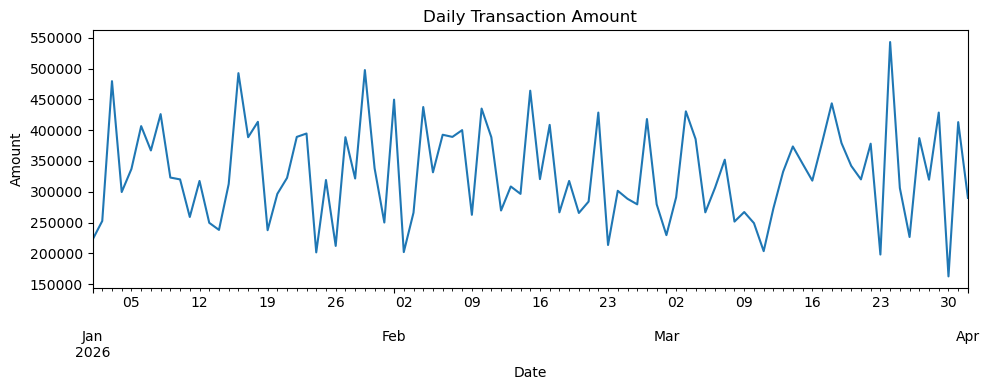

In [78]:
daily_amount = bank.groupby("Date")["Amount"].sum()
daily_amount.plot(kind="line", figsize=(10,4), title="Daily Transaction Amount")
plt.ylabel("Amount")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

Transaction_Type  Deposit  Withdrawal
Date                                 
2026-01-01          79500      142500
2026-01-02         105000      147500
2026-01-03         364000      115500
2026-01-04         222500       77000
2026-01-05         262000       75000
...                   ...         ...
2026-03-28         184000      135500
2026-03-29         263000      165500
2026-03-30          51000      111500
2026-03-31         256500      156500
2026-04-01          95500      194500

[91 rows x 2 columns]


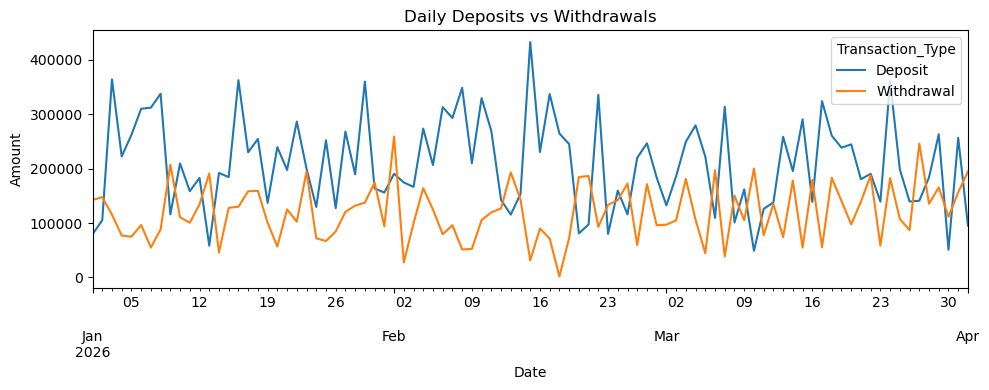

In [79]:
daily_type = bank.pivot_table(index="Date", columns="Transaction_Type",
                              values="Amount", aggfunc="sum")

print(daily_type)
daily_type.plot(kind="line", figsize=(10,4), title="Daily Deposits vs Withdrawals")
plt.ylabel("Amount")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

Branch
Karachi      11860000
Lahore        9210500
Islamabad     8956500
Name: Amount, dtype: int64


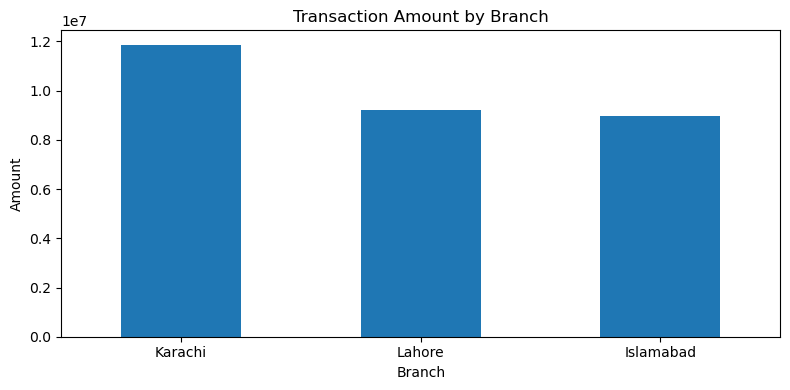

In [80]:
branch_amount = bank.groupby("Branch")["Amount"].sum().sort_values(ascending=False)
print(branch_amount)

branch_amount.plot(kind="bar", figsize=(8,4), title="Transaction Amount by Branch")
plt.ylabel("Amount")
plt.xlabel("Branch")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

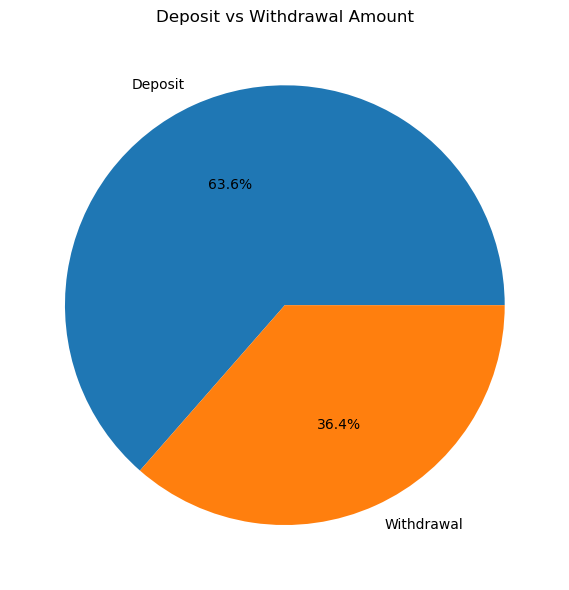

In [81]:
type_amount = bank.groupby("Transaction_Type")["Amount"].sum()
type_amount.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6), title="Deposit vs Withdrawal Amount")
plt.ylabel("")
plt.tight_layout()
plt.show()

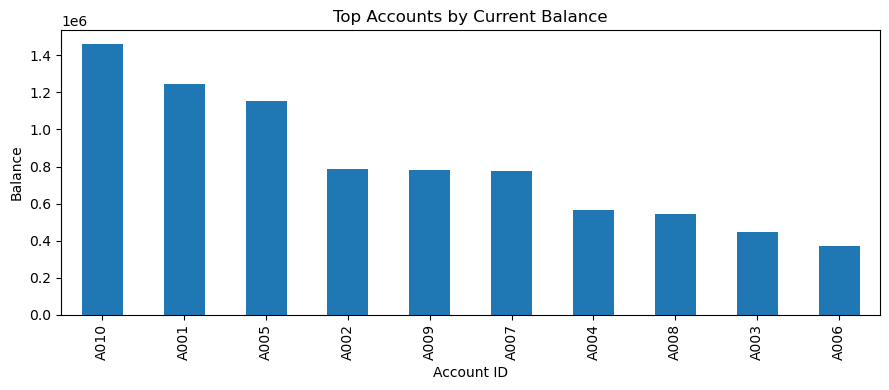

In [82]:
top_balance = balance.sort_values("Current_Balance", ascending=False).head(10)
top_balance.set_index("Account_ID")["Current_Balance"].plot(
    kind="bar", figsize=(9,4), title="Top Accounts by Current Balance"
)
plt.ylabel("Balance")
plt.xlabel("Account ID")
plt.tight_layout()
plt.show()

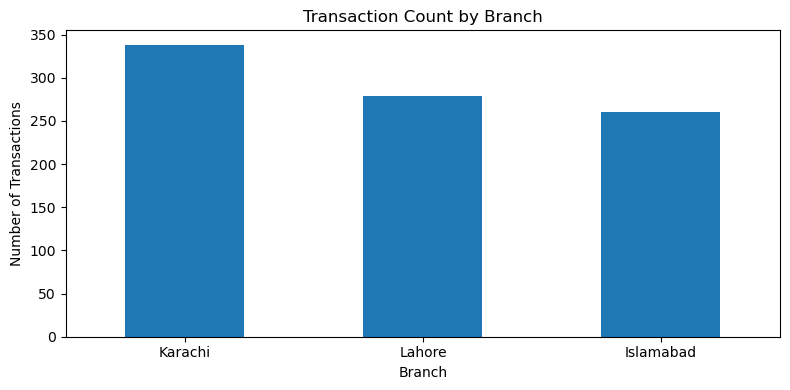

In [83]:
# Graph 6 Number of transactions by branch
branch_count = bank["Branch"].value_counts()
branch_count.plot(kind="bar", figsize=(8,4), title="Transaction Count by Branch")
plt.ylabel("Number of Transactions")
plt.xlabel("Branch")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

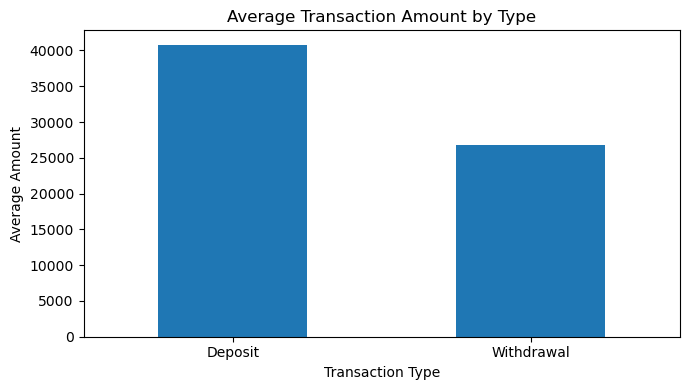

In [84]:
# Graph 7 Average transaction amount by type
avg_type = bank.groupby("Transaction_Type")["Amount"].mean()
avg_type.plot(kind="bar", figsize=(7,4), title="Average Transaction Amount by Type")
plt.ylabel("Average Amount")
plt.xlabel("Transaction Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()